In [ ]:
# ============================================
#  Downloading the master RECORDS file
# ============================================

!wget -q https://physionet.org/files/mimic4wdb/0.1.0/RECORDS
print("RECORDS file downloaded successfully.\n")

!head RECORDS

RECORDS file downloaded successfully.

waves/p100/p10014354/
waves/p100/p10019003/
waves/p100/p10020306/
waves/p100/p10039708/
waves/p100/p10079700/
waves/p100/p10082591/
waves/p101/p10100546/
waves/p101/p10112163/
waves/p101/p10126957/
waves/p102/p10209410/


In [ ]:
# ============================================
# Reading patient folder paths
# ============================================

with open("RECORDS", "r") as f:
    patient_paths = [line.strip() for line in f if line.strip()]

print("Total patient folders available:", len(patient_paths))
print("\nFirst 15 patient folders:\n")

for p in patient_paths[:15]:
    print(p)

Total patient folders available: 198

First 15 patient folders:

waves/p100/p10014354/
waves/p100/p10019003/
waves/p100/p10020306/
waves/p100/p10039708/
waves/p100/p10079700/
waves/p100/p10082591/
waves/p101/p10100546/
waves/p101/p10112163/
waves/p101/p10126957/
waves/p102/p10209410/
waves/p103/p10303080/
waves/p104/p10494990/
waves/p105/p10560354/
waves/p106/p10680081/
waves/p108/p10882818/


In [ ]:
# ============================================
# 10 patient folders
# ============================================

selected_patients = patient_paths[:10]

print("Selected 10 patient folders:\n")
for p in selected_patients:
    print(p)

Selected 10 patient folders:

waves/p100/p10014354/
waves/p100/p10019003/
waves/p100/p10020306/
waves/p100/p10039708/
waves/p100/p10079700/
waves/p100/p10082591/
waves/p101/p10100546/
waves/p101/p10112163/
waves/p101/p10126957/
waves/p102/p10209410/


In [ ]:
# ============================================
# Download 10 selected patient folders
# ============================================

base_url = "https://physionet.org/files/mimic4wdb/0.1.0/"

for p in selected_patients:
    url = base_url + p
    print(f"Downloading: {url}")
    !wget -r -N -c -np -q $url

print("\nDownload of selected patient folders completed.")

Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/
Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10019003/
Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10020306/
Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10039708/
Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10079700/
Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10082591/
Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p101/p10100546/
Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p101/p10112163/
Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p101/p10126957/
Downloading: https://physionet.org/files/mimic4wdb/0.1.0/waves/p102/p10209410/

Download of selected patient folders completed.


In [ ]:
# ============================================
# Mounting Google Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================
# Downloaded waveform files to Drive
# ============================================

!mkdir -p /content/drive/MyDrive/mimic_waveform_project
!cp -r /content/physionet.org /content/drive/MyDrive/mimic_waveform_project/

print("Dataset copied to Google Drive successfully.")

Dataset copied to Google Drive successfully.


In [ ]:
# ============================================
# Verifying saved files in Google Drive
# ============================================

!find /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves -type f | head -50

/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/index.html
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/index.html
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927.hea
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0000.hea
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0001.hea
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0001e.dat
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0001r.dat
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/8173

In [ ]:
# ============================================
# Dataset path
# ============================================

BASE_PATH = "/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves"
print(BASE_PATH)

/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves


**Install and import required libraries**

In [ ]:
# ============================================
# Install required packages
# ============================================

!pip install wfdb -q
!pip install scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 108.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.


In [ ]:
# ============================================
# Importing required libraries
# ============================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# ============================================
# Finding all header files
# ============================================

import os
import glob

hea_files = sorted(glob.glob(BASE_PATH + "/**/*.hea", recursive=True))

print("Total .hea files found:", len(hea_files))
print("\nFirst 20 header files:\n")

for f in hea_files[:20]:
    print(f)

Total .hea files found: 401

First 20 header files:

/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927.hea
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0000.hea
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0001.hea
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0002.hea
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0003.hea
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0004.hea
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0005.hea
/content/drive/MyDrive/mimic_waveform_proj

In [ ]:
# ============================================
# Identifying true main record headers
# ============================================

main_records = []

for hf in hea_files:
    filename = os.path.basename(hf)


    if "_" not in filename:
        main_records.append(hf.replace(".hea", ""))

print("Total true main record files found:", len(main_records))
print("\nTrue main record files:\n")

for rec in main_records:
    print(rec)

Total true main record files found: 11

True main record files:

/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10019003/87033314/87033314
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10020306/83404654/83404654
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10039708/83411188/83411188
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10039708/85583557/85583557
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10079700/85594648/85594648
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10082591/84050536/84050536
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/

**Extract usable waveform segments**

In [ ]:
# ============================================
# Extract usable waveform segments
# ============================================

import wfdb
import pandas as pd
import os

usable_segments = []

for main_record in main_records:
    try:
        hdr = wfdb.rdheader(main_record)

        for seg_name, seg_len in zip(hdr.seg_name, hdr.seg_len):
            if seg_name is not None and seg_len > 10000:
                seg_path = os.path.join(os.path.dirname(main_record), seg_name)
                usable_segments.append({
                    "main_record": os.path.basename(main_record),
                    "segment_name": seg_name,
                    "segment_path": seg_path,
                    "segment_length": seg_len
                })
    except Exception as e:
        print(f"Skipping {main_record} because of error: {e}")

usable_segments_df = pd.DataFrame(usable_segments)

print("Total usable segments found:", len(usable_segments_df))
usable_segments_df.head(20)

Total usable segments found: 158


,main_record,segment_name,segment_path,segment_length
0,81739927,81739927_0008,/content/drive/MyDrive/mimic_waveform_project/...,1431360
1,81739927,81739927_0010,/content/drive/MyDrive/mimic_waveform_project/...,641280
2,81739927,81739927_0012,/content/drive/MyDrive/mimic_waveform_project/...,776320
3,81739927,81739927_0014,/content/drive/MyDrive/mimic_waveform_project/...,1227840
4,81739927,81739927_0015,/content/drive/MyDrive/mimic_waveform_project/...,23360
5,81739927,81739927_0016,/content/drive/MyDrive/mimic_waveform_project/...,741760
6,81739927,81739927_0017,/content/drive/MyDrive/mimic_waveform_project/...,1236800
7,81739927,81739927_0020,/content/drive/MyDrive/mimic_waveform_project/...,566400
8,87033314,87033314_0001,/content/drive/MyDrive/mimic_waveform_project/...,19520
9,87033314,87033314_0005,/content/drive/MyDrive/mimic_waveform_project/...,1285760


In [ ]:
# ============================================
# Summary of usable segments
# ============================================

print("Usable segment table shape:", usable_segments_df.shape)
print("\nSegment length summary:\n")
print(usable_segments_df["segment_length"].describe())

Usable segment table shape: (158, 4)

Segment length summary:

count    1.580000e+02
mean     7.340693e+05
std      1.613027e+06
min      1.056000e+04
25%      6.600000e+04
50%      2.512000e+05
75%      7.647480e+05
max      1.347680e+07
Name: segment_length, dtype: float64


**Inspect signal channels and filter segments**

In [ ]:
# ============================================
# Inspect signal names of usable segments
# ============================================

segment_info = []

for _, row in usable_segments_df.iterrows():
    try:
        hdr = wfdb.rdheader(row["segment_path"])
        segment_info.append({
            "segment_path": row["segment_path"],
            "segment_length": row["segment_length"],
            "n_signals": hdr.n_sig,
            "signal_names": hdr.sig_name
        })
    except Exception as e:
        print(f"Skipping {row['segment_path']} because of error: {e}")

segment_info_df = pd.DataFrame(segment_info)

print("Segments successfully inspected:", len(segment_info_df))
segment_info_df.head(10)

Skipping /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10019003/87033314/~ because of error: [Errno 2] No such file or directory: '/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10019003/87033314/~.hea'
Skipping /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10020306/83404654/~ because of error: [Errno 2] No such file or directory: '/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10020306/83404654/~.hea'
Skipping /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10079700/85594648/~ because of error: [Errno 2] No such file or directory: '/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10079700/85594648/~.hea'
Skipping /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p101/p101

,segment_path,segment_length,n_signals,signal_names
0,/content/drive/MyDrive/mimic_waveform_project/...,1431360,5,"[II, V, aVR, Pleth, Resp]"
1,/content/drive/MyDrive/mimic_waveform_project/...,641280,5,"[II, V, aVR, Pleth, Resp]"
2,/content/drive/MyDrive/mimic_waveform_project/...,776320,5,"[II, V, aVR, Pleth, Resp]"
3,/content/drive/MyDrive/mimic_waveform_project/...,1227840,5,"[II, V, aVR, Pleth, Resp]"
4,/content/drive/MyDrive/mimic_waveform_project/...,23360,4,"[II, V, aVR, Resp]"
5,/content/drive/MyDrive/mimic_waveform_project/...,741760,5,"[II, V, aVR, Pleth, Resp]"
6,/content/drive/MyDrive/mimic_waveform_project/...,1236800,5,"[III, V, II, Pleth, Resp]"
7,/content/drive/MyDrive/mimic_waveform_project/...,566400,5,"[III, V, II, Pleth, Resp]"
8,/content/drive/MyDrive/mimic_waveform_project/...,19520,5,"[II, V, aVR, Pleth, Resp]"
9,/content/drive/MyDrive/mimic_waveform_project/...,1285760,5,"[II, V, aVR, Pleth, Resp]"


In [ ]:
# ============================================
#Filter segments with II, Pleth, Resp
# ============================================

required_channels = {"II", "Pleth", "Resp"}

def has_required_channels(sig_list):
    return required_channels.issubset(set(sig_list))

segment_info_df["use_segment"] = segment_info_df["signal_names"].apply(has_required_channels)

filtered_segments_df = segment_info_df[segment_info_df["use_segment"] == True].copy()

print("Segments with II, Pleth, and Resp:", len(filtered_segments_df))
filtered_segments_df.head(20)

Segments with II, Pleth, and Resp: 101


,segment_path,segment_length,n_signals,signal_names,use_segment
0,/content/drive/MyDrive/mimic_waveform_project/...,1431360,5,"[II, V, aVR, Pleth, Resp]",True
1,/content/drive/MyDrive/mimic_waveform_project/...,641280,5,"[II, V, aVR, Pleth, Resp]",True
2,/content/drive/MyDrive/mimic_waveform_project/...,776320,5,"[II, V, aVR, Pleth, Resp]",True
3,/content/drive/MyDrive/mimic_waveform_project/...,1227840,5,"[II, V, aVR, Pleth, Resp]",True
5,/content/drive/MyDrive/mimic_waveform_project/...,741760,5,"[II, V, aVR, Pleth, Resp]",True
6,/content/drive/MyDrive/mimic_waveform_project/...,1236800,5,"[III, V, II, Pleth, Resp]",True
7,/content/drive/MyDrive/mimic_waveform_project/...,566400,5,"[III, V, II, Pleth, Resp]",True
8,/content/drive/MyDrive/mimic_waveform_project/...,19520,5,"[II, V, aVR, Pleth, Resp]",True
9,/content/drive/MyDrive/mimic_waveform_project/...,1285760,5,"[II, V, aVR, Pleth, Resp]",True
10,/content/drive/MyDrive/mimic_waveform_project/...,16640,5,"[III, V, II, Pleth, Resp]",True


**Exploratory Data Analysis (EDA)**

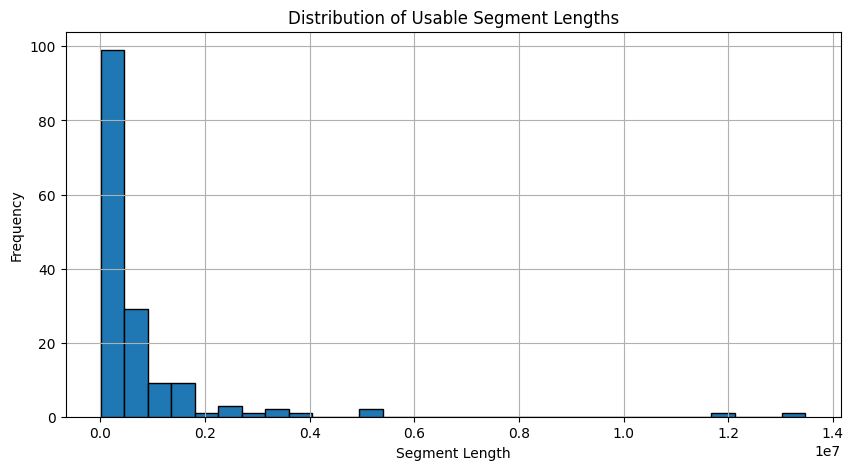

In [ ]:
# ============================================
# Distribution of usable segment lengths
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(usable_segments_df["segment_length"], bins=30, edgecolor="black")
plt.title("Distribution of Usable Segment Lengths")
plt.xlabel("Segment Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

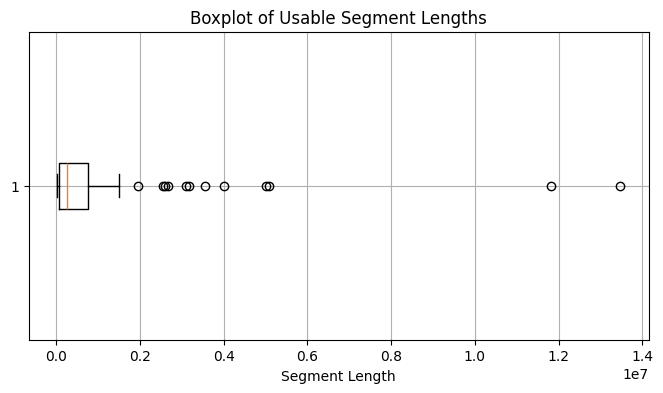

In [ ]:
# ============================================
#  Boxplot of usable segment lengths
# ============================================

plt.figure(figsize=(8, 4))
plt.boxplot(usable_segments_df["segment_length"], vert=False)
plt.title("Boxplot of Usable Segment Lengths")
plt.xlabel("Segment Length")
plt.grid(True)
plt.show()

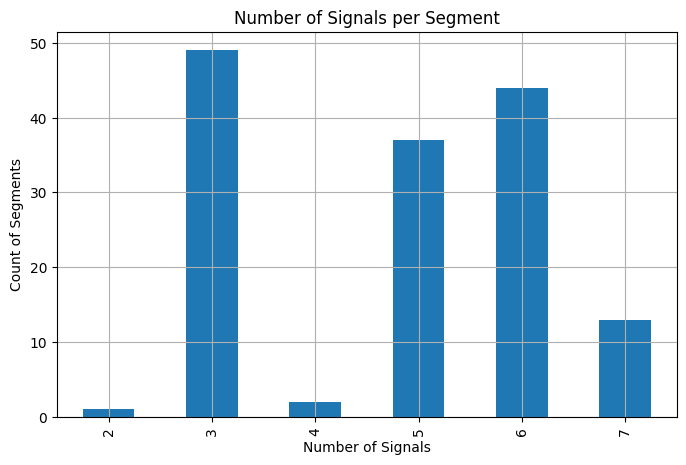

In [ ]:
# ============================================
# Number of signals per segment
# ============================================

signal_count_series = segment_info_df["n_signals"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
signal_count_series.plot(kind="bar")
plt.title("Number of Signals per Segment")
plt.xlabel("Number of Signals")
plt.ylabel("Count of Segments")
plt.grid(True)
plt.show()

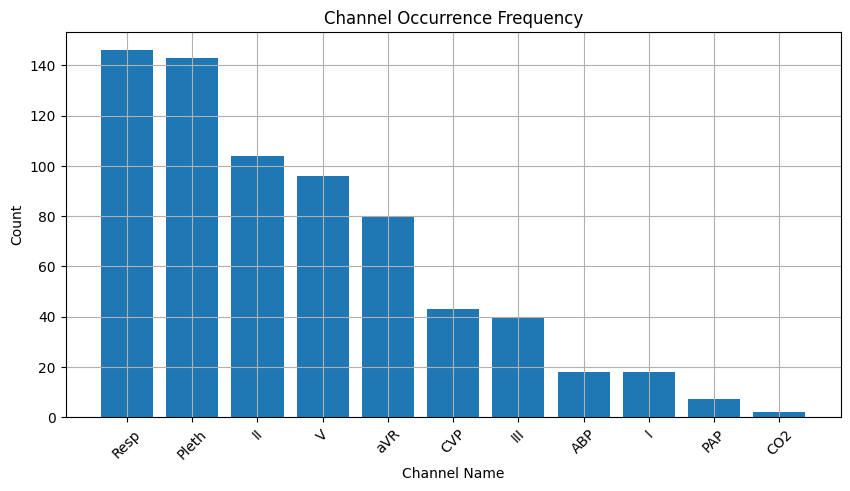

,channel,count
4,Resp,146
3,Pleth,143
0,II,104
1,V,96
2,aVR,80
8,CVP,43
5,III,40
6,ABP,18
7,I,18
9,PAP,7


In [ ]:
# ============================================
# Channel occurrence frequency
# ============================================

from collections import Counter

all_channels = []
for sig_list in segment_info_df["signal_names"]:
    all_channels.extend(sig_list)

channel_counts = Counter(all_channels)
channel_df = pd.DataFrame(channel_counts.items(), columns=["channel", "count"]).sort_values(
    by="count", ascending=False
)

plt.figure(figsize=(10, 5))
plt.bar(channel_df["channel"], channel_df["count"])
plt.title("Channel Occurrence Frequency")
plt.xlabel("Channel Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

channel_df

In [ ]:
# ============================================
# Finding one valid non-empty segment
# ============================================

selected_channels = ["II", "Pleth", "Resp"]

valid_plot_segment = None
valid_plot_df = None

for _, row in filtered_segments_df.iterrows():
    seg_path = row["segment_path"]
    seg_len = int(row["segment_length"])

    try:

        safe_sampto = min(3000, seg_len)

        rec = wfdb.rdrecord(
            seg_path,
            sampfrom=0,
            sampto=safe_sampto,
            smooth_frames=False
        )

        # Convert to DataFrame
        df_temp = pd.DataFrame(rec.p_signal, columns=rec.sig_name)


        if len(df_temp) > 0 and all(ch in df_temp.columns for ch in selected_channels):
            valid_plot_segment = seg_path
            valid_plot_df = df_temp[selected_channels].copy()
            break

    except Exception as e:
        continue

if valid_plot_segment is not None:
    print("Valid segment found:")
    print(valid_plot_segment)
    print("Data shape:", valid_plot_df.shape)
    print(valid_plot_df.head())
else:
    print("No valid segment found.")

No valid segment found.


In [ ]:
# ============================================
# Plot one clean sample waveform
# ============================================

if valid_plot_df is not None:
    plt.figure(figsize=(15, 8))

    for i, col in enumerate(selected_channels):
        plt.subplot(len(selected_channels), 1, i + 1)
        plt.plot(valid_plot_df[col].values[:2000])
        plt.title(f"Sample Raw Waveform: {col}")
        plt.xlabel("Sample Index")
        plt.ylabel("Amplitude")
        plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot because valid_plot_df is None.")

Cannot plot because valid_plot_df is None.


In [ ]:
# ============================================
# Testing one filtered segment using rdsamp
# ============================================

test_segment = filtered_segments_df.iloc[0]["segment_path"]
test_len = int(filtered_segments_df.iloc[0]["segment_length"])

safe_sampto = min(1000, test_len)

signals, fields = wfdb.rdsamp(
    test_segment,
    sampfrom=0,
    sampto=safe_sampto
)

print("Test segment path:")
print(test_segment)

print("\nSignal array shape:", signals.shape)
print("Signal names:", fields["sig_name"])
print("\nFirst 5 rows:\n")
print(signals[:5])

Test segment path:
/content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10014354/81739927/81739927_0008

Signal array shape: (1000, 5)
Signal names: ['II', 'V', 'aVR', 'Pleth', 'Resp']

First 5 rows:

[[ 0.1        -0.105      -0.02        0.46557617  0.70372633]
 [-0.245      -0.8         0.09        0.4609375   0.64386072]
 [-0.625      -0.675       0.31        0.45629883  0.57544288]
 [-0.27       -0.085       0.14        0.45336914  0.49602932]
 [-0.13        0.115       0.055       0.45581055  0.4086744 ]]


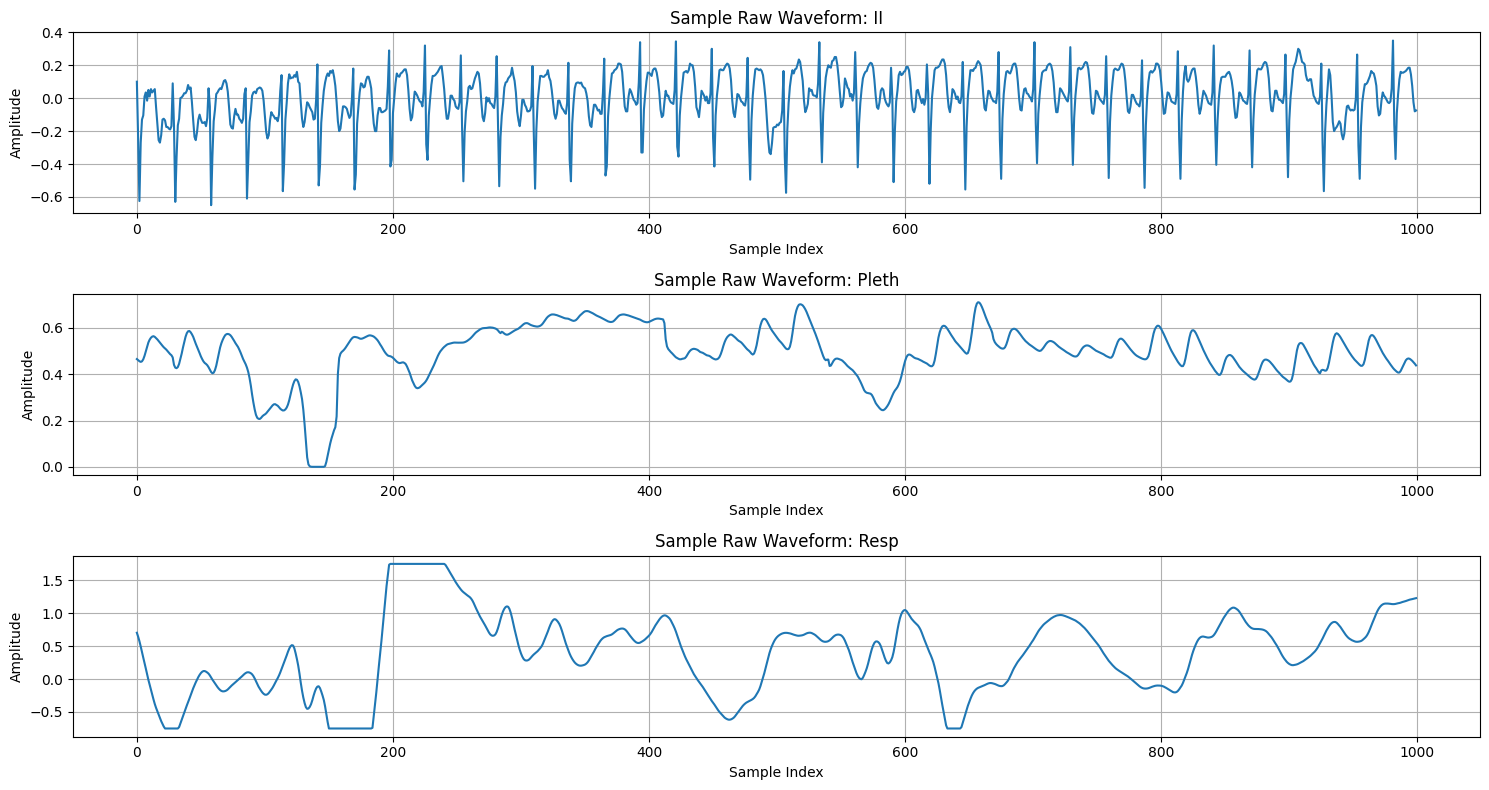

In [ ]:
# ============================================
# Plot one clean sample waveform
# ============================================

selected_channels = ["II", "Pleth", "Resp"]

df_plot = pd.DataFrame(signals, columns=fields["sig_name"])

plt.figure(figsize=(15, 8))

for i, col in enumerate(selected_channels):
    if col in df_plot.columns:
        plt.subplot(len(selected_channels), 1, i + 1)
        plt.plot(df_plot[col].values[:1000])
        plt.title(f"Sample Raw Waveform: {col}")
        plt.xlabel("Sample Index")
        plt.ylabel("Amplitude")
        plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Build loadable segments table using rdsamp
# ============================================

loadable_segments = []

for _, row in filtered_segments_df.iterrows():
    seg_path = row["segment_path"]
    seg_len = int(row["segment_length"])

    try:
        safe_sampto = min(1000, seg_len)

        signals, fields = wfdb.rdsamp(
            seg_path,
            sampfrom=0,
            sampto=safe_sampto
        )

        if signals is not None and signals.shape[0] > 0:
            loadable_segments.append({
                "segment_path": seg_path,
                "segment_length": seg_len,
                "signal_names": fields["sig_name"],
                "shape": signals.shape
            })

    except Exception:
        continue

loadable_segments_df = pd.DataFrame(loadable_segments)

print("Total loadable segments found:", len(loadable_segments_df))
loadable_segments_df.head(10)

Total loadable segments found: 101


,segment_path,segment_length,signal_names,shape
0,/content/drive/MyDrive/mimic_waveform_project/...,1431360,"[II, V, aVR, Pleth, Resp]","(1000, 5)"
1,/content/drive/MyDrive/mimic_waveform_project/...,641280,"[II, V, aVR, Pleth, Resp]","(1000, 5)"
2,/content/drive/MyDrive/mimic_waveform_project/...,776320,"[II, V, aVR, Pleth, Resp]","(1000, 5)"
3,/content/drive/MyDrive/mimic_waveform_project/...,1227840,"[II, V, aVR, Pleth, Resp]","(1000, 5)"
4,/content/drive/MyDrive/mimic_waveform_project/...,741760,"[II, V, aVR, Pleth, Resp]","(1000, 5)"
5,/content/drive/MyDrive/mimic_waveform_project/...,1236800,"[III, V, II, Pleth, Resp]","(1000, 5)"
6,/content/drive/MyDrive/mimic_waveform_project/...,566400,"[III, V, II, Pleth, Resp]","(1000, 5)"
7,/content/drive/MyDrive/mimic_waveform_project/...,19520,"[II, V, aVR, Pleth, Resp]","(1000, 5)"
8,/content/drive/MyDrive/mimic_waveform_project/...,1285760,"[II, V, aVR, Pleth, Resp]","(1000, 5)"
9,/content/drive/MyDrive/mimic_waveform_project/...,16640,"[III, V, II, Pleth, Resp]","(1000, 5)"


In [ ]:

required_channels = {"II", "Pleth", "Resp"}

def has_required_channels(sig_list):
    return required_channels.issubset(set(sig_list))

loadable_segments_df["use_segment"] = loadable_segments_df["signal_names"].apply(has_required_channels)

final_segments_df = loadable_segments_df[loadable_segments_df["use_segment"] == True].copy()

print("Final usable + loadable segments:", len(final_segments_df))
final_segments_df.head(10)

Final usable + loadable segments: 101


,segment_path,segment_length,signal_names,shape,use_segment
0,/content/drive/MyDrive/mimic_waveform_project/...,1431360,"[II, V, aVR, Pleth, Resp]","(1000, 5)",True
1,/content/drive/MyDrive/mimic_waveform_project/...,641280,"[II, V, aVR, Pleth, Resp]","(1000, 5)",True
2,/content/drive/MyDrive/mimic_waveform_project/...,776320,"[II, V, aVR, Pleth, Resp]","(1000, 5)",True
3,/content/drive/MyDrive/mimic_waveform_project/...,1227840,"[II, V, aVR, Pleth, Resp]","(1000, 5)",True
4,/content/drive/MyDrive/mimic_waveform_project/...,741760,"[II, V, aVR, Pleth, Resp]","(1000, 5)",True
5,/content/drive/MyDrive/mimic_waveform_project/...,1236800,"[III, V, II, Pleth, Resp]","(1000, 5)",True
6,/content/drive/MyDrive/mimic_waveform_project/...,566400,"[III, V, II, Pleth, Resp]","(1000, 5)",True
7,/content/drive/MyDrive/mimic_waveform_project/...,19520,"[II, V, aVR, Pleth, Resp]","(1000, 5)",True
8,/content/drive/MyDrive/mimic_waveform_project/...,1285760,"[II, V, aVR, Pleth, Resp]","(1000, 5)",True
9,/content/drive/MyDrive/mimic_waveform_project/...,16640,"[III, V, II, Pleth, Resp]","(1000, 5)",True


In [ ]:
# ============================================
# longest segments for modelling
# ============================================

final_segments_df = final_segments_df.sort_values(
    by="segment_length",
    ascending=False
).reset_index(drop=True)

top_n_segments = 40
final_segments_top_df = final_segments_df.head(top_n_segments).copy()

print("Top segments selected for modelling:", len(final_segments_top_df))
final_segments_top_df[["segment_path", "segment_length"]].head(20)

Top segments selected for modelling: 40


,segment_path,segment_length
0,/content/drive/MyDrive/mimic_waveform_project/...,13476800
1,/content/drive/MyDrive/mimic_waveform_project/...,11808960
2,/content/drive/MyDrive/mimic_waveform_project/...,5083200
3,/content/drive/MyDrive/mimic_waveform_project/...,5010240
4,/content/drive/MyDrive/mimic_waveform_project/...,4012160
5,/content/drive/MyDrive/mimic_waveform_project/...,3545280
6,/content/drive/MyDrive/mimic_waveform_project/...,3176000
7,/content/drive/MyDrive/mimic_waveform_project/...,3096960
8,/content/drive/MyDrive/mimic_waveform_project/...,2667840
9,/content/drive/MyDrive/mimic_waveform_project/...,2598400


In [ ]:
# ============================================
#  modelling data loading function
# ============================================

selected_channels = ["II", "Pleth", "Resp"]

def load_selected_channels_rdsamp(segment_path, max_samples=20000):
    """
    Load selected channels from one segment using wfdb.rdsamp
    """
    signals, fields = wfdb.rdsamp(
        segment_path,
        sampfrom=0,
        sampto=max_samples
    )

    df = pd.DataFrame(signals, columns=fields["sig_name"])
    df = df[selected_channels].copy()
    df["segment_path"] = segment_path
    df["segment_length_used"] = len(df)

    return df

In [ ]:
# ============================================
# Waveform data from top segments
# ============================================

all_dfs = []

for i, seg_path in enumerate(final_segments_top_df["segment_path"]):
    try:
        df_seg = load_selected_channels_rdsamp(seg_path, max_samples=20000)
        all_dfs.append(df_seg)
        print(f"[{i+1}/{len(final_segments_top_df)}] Loaded: {seg_path} -> shape {df_seg.shape}")
    except Exception as e:
        print(f"Skipping {seg_path} because of error: {e}")

combined_df = pd.concat(all_dfs, axis=0, ignore_index=True)

print("\nCombined waveform data shape:", combined_df.shape)
combined_df.head()

[1/40] Loaded: /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10019003/87033314/87033314_0007 -> shape (20000, 5)
[2/40] Loaded: /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10079700/85594648/85594648_0003 -> shape (20000, 5)
[3/40] Loaded: /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10020306/83404654/83404654_0019 -> shape (20000, 5)
[4/40] Loaded: /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p101/p10112163/88501826/88501826_0058 -> shape (20000, 5)
[5/40] Loaded: /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p100/p10020306/83404654/83404654_0011 -> shape (20000, 5)
[6/40] Loaded: /content/drive/MyDrive/mimic_waveform_project/physionet.org/files/mimic4wdb/0.1.0/waves/p101/p10126957/82924339/82924339_0011 -> shape (20000, 5)
[7/40] Loaded: /content/drive/MyDr

,II,Pleth,Resp,segment_path,segment_length_used
0,-1.635,0.202393,-0.000489,/content/drive/MyDrive/mimic_waveform_project/...,20000
1,-1.575,0.197998,-0.000489,/content/drive/MyDrive/mimic_waveform_project/...,20000
2,-1.505,0.196533,-0.000489,/content/drive/MyDrive/mimic_waveform_project/...,20000
3,-1.475,0.193359,-0.000489,/content/drive/MyDrive/mimic_waveform_project/...,20000
4,-1.400,0.188965,-0.000489,/content/drive/MyDrive/mimic_waveform_project/...,20000


In [ ]:
# ============================================
# Inspect combined modelling dataset
# ============================================

print("Combined dataset shape:", combined_df.shape)
print("\nColumns:", combined_df.columns.tolist())
print("\nUnique segments loaded:", combined_df["segment_path"].nunique())

Combined dataset shape: (800000, 5)

Columns: ['II', 'Pleth', 'Resp', 'segment_path', 'segment_length_used']

Unique segments loaded: 40


In [ ]:
# ============================================
# combined raw waveform dataset
# ============================================

combined_df.to_csv(
    "/content/drive/MyDrive/mimic_waveform_project/combined_waveform_raw.csv",
    index=False
)

print("Combined raw waveform dataset saved to Drive.")

Combined raw waveform dataset saved to Drive.


<Figure size 1000x600 with 0 Axes>

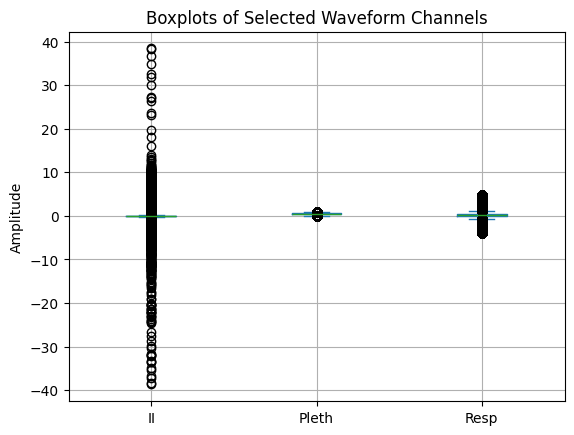

In [ ]:
# ============================================
#  Boxplots of selected channels
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
combined_df[["II", "Pleth", "Resp"]].plot(kind="box")
plt.title("Boxplots of Selected Waveform Channels")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

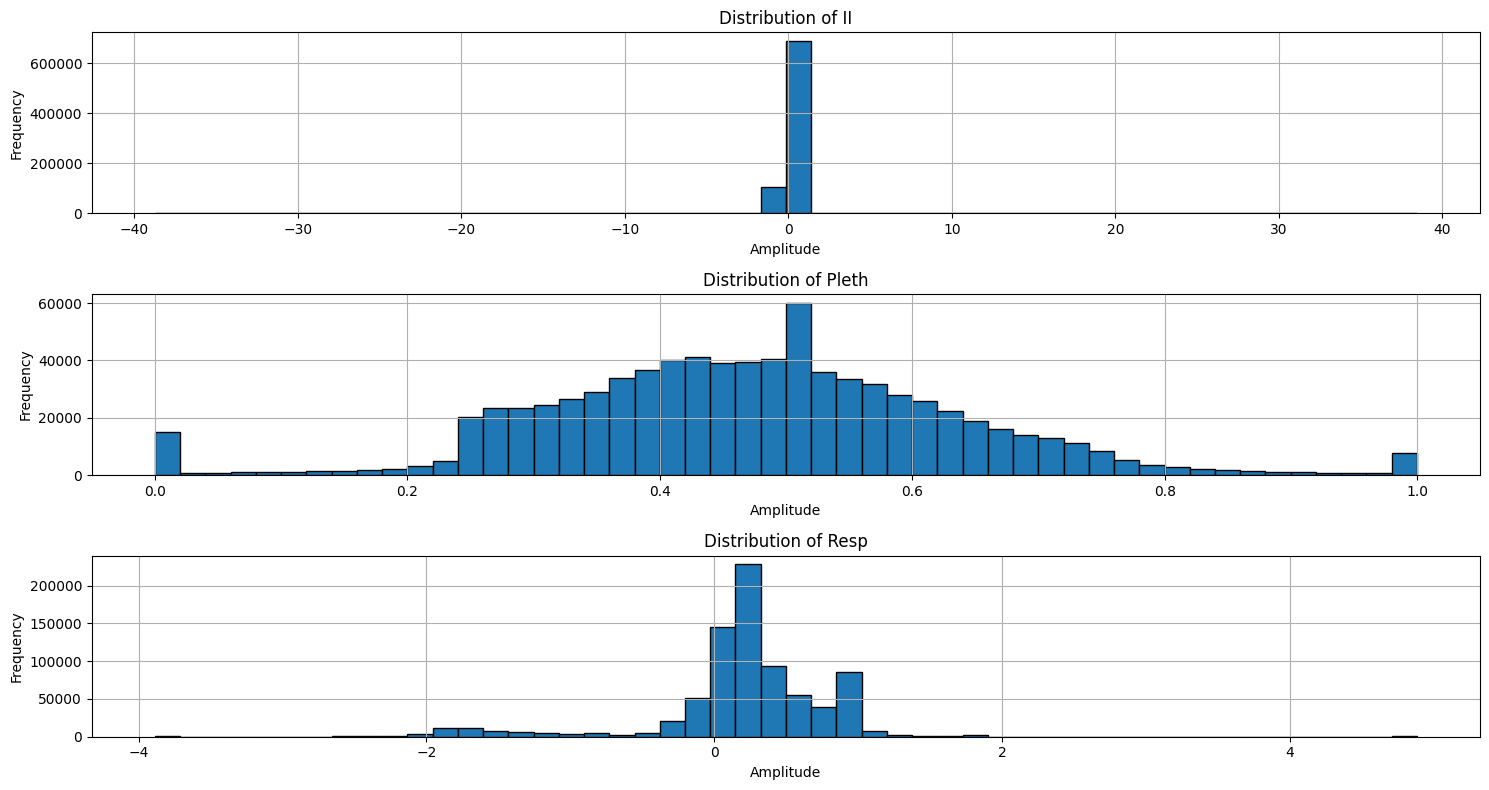

In [ ]:
# ============================================
#  Histograms of selected channels
# ============================================

plt.figure(figsize=(15, 8))

for i, col in enumerate(["II", "Pleth", "Resp"]):
    plt.subplot(3, 1, i+1)
    plt.hist(combined_df[col].values, bins=50, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel("Amplitude")
    plt.ylabel("Frequency")
    plt.grid(True)

plt.tight_layout()
plt.show()

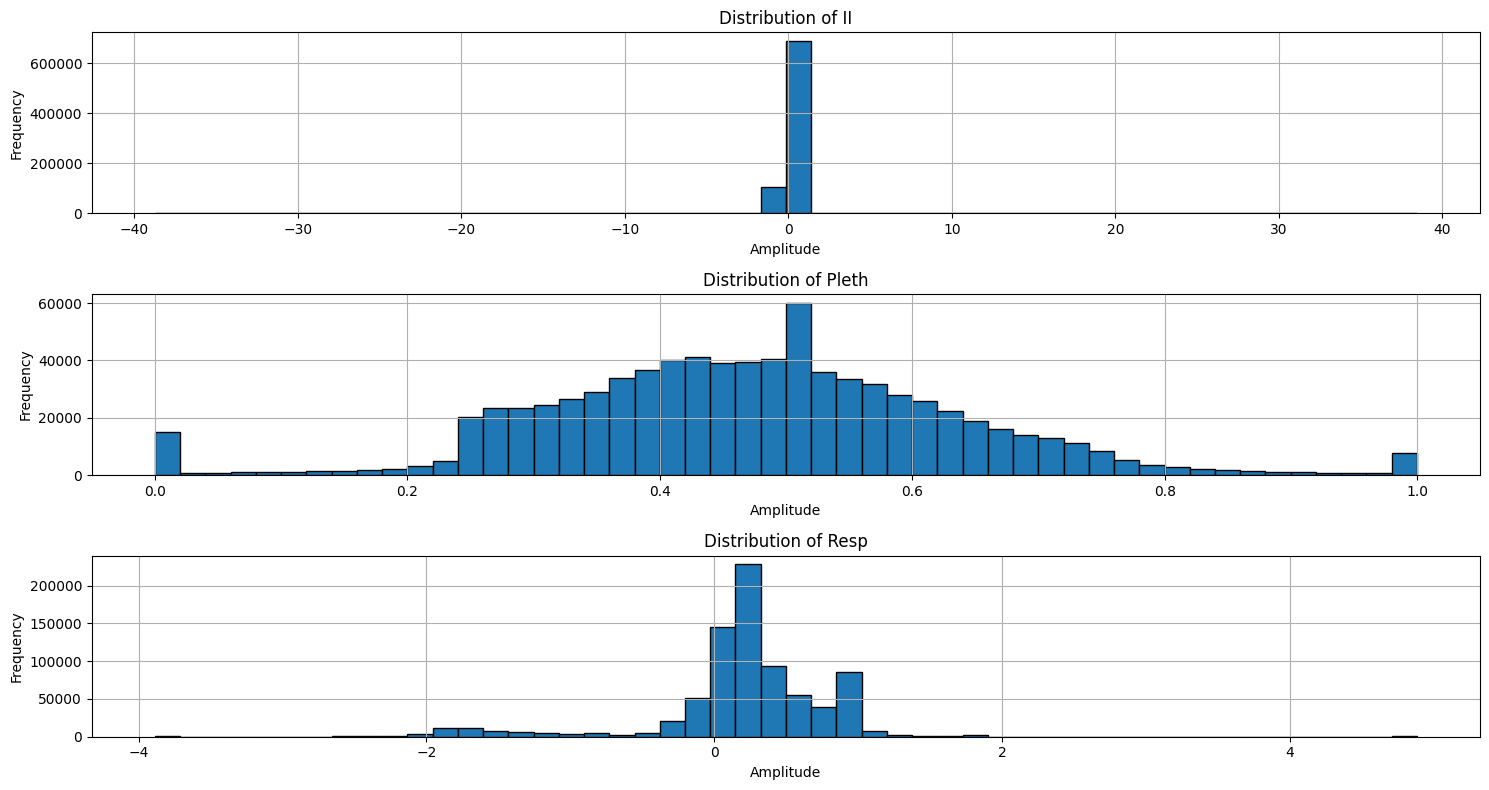

In [ ]:
# ============================================
#  Histograms of selected channels
# ============================================

plt.figure(figsize=(15, 8))

for i, col in enumerate(["II", "Pleth", "Resp"]):
    plt.subplot(3, 1, i+1)
    plt.hist(combined_df[col].values, bins=50, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel("Amplitude")
    plt.ylabel("Frequency")
    plt.grid(True)

plt.tight_layout()
plt.show()

**Preprocessing**

In [ ]:
# ============================================
#  Check missing values
# ============================================

print("Missing values per column:\n")
print(combined_df.isnull().sum())

Missing values per column:

II                     1538
Pleth                     0
Resp                      0
segment_path              0
segment_length_used       0
dtype: int64


In [ ]:
# ============================================
# Remove missing values
# ============================================

combined_df = combined_df.dropna().reset_index(drop=True)

print("Shape after dropping missing values:", combined_df.shape)

Shape after dropping missing values: (798462, 5)


In [ ]:
# ============================================
#  Standardize waveform channels
# ============================================

from sklearn.preprocessing import StandardScaler
import pandas as pd

signal_cols = ["II", "Pleth", "Resp"]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(combined_df[signal_cols])

scaled_df = pd.DataFrame(scaled_data, columns=signal_cols)
scaled_df["segment_path"] = combined_df["segment_path"].values
scaled_df["segment_length_used"] = combined_df["segment_length_used"].values

print("Scaled dataset shape:", scaled_df.shape)
scaled_df.head()

Scaled dataset shape: (798462, 5)


,II,Pleth,Resp,segment_path,segment_length_used
0,-3.945153,-1.672338,-0.317423,/content/drive/MyDrive/mimic_waveform_project/...,20000
1,-3.799820,-1.699393,-0.317423,/content/drive/MyDrive/mimic_waveform_project/...,20000
2,-3.630264,-1.708412,-0.317423,/content/drive/MyDrive/mimic_waveform_project/...,20000
3,-3.557598,-1.727952,-0.317423,/content/drive/MyDrive/mimic_waveform_project/...,20000
4,-3.375932,-1.755007,-0.317423,/content/drive/MyDrive/mimic_waveform_project/...,20000


In [ ]:
# ============================================
# : Save scaled dataset
# ============================================

scaled_df.to_csv(
    "/content/drive/MyDrive/mimic_waveform_project/combined_waveform_scaled.csv",
    index=False
)

print("Scaled waveform dataset saved to Drive.")

Scaled waveform dataset saved to Drive.


**Windowing**

In [ ]:
# ============================================
#  Create fixed-length windows
# ============================================

import numpy as np

def create_windows(data, window_size=128, stride=64):
    windows = []
    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        windows.append(data[start:end])
    return np.array(windows)

signal_cols = ["II", "Pleth", "Resp"]
window_size = 128
stride = 64

X = create_windows(
    scaled_df[signal_cols].values,
    window_size=window_size,
    stride=stride
)

print("Windowed data shape:", X.shape)

Windowed data shape: (12474, 128, 3)


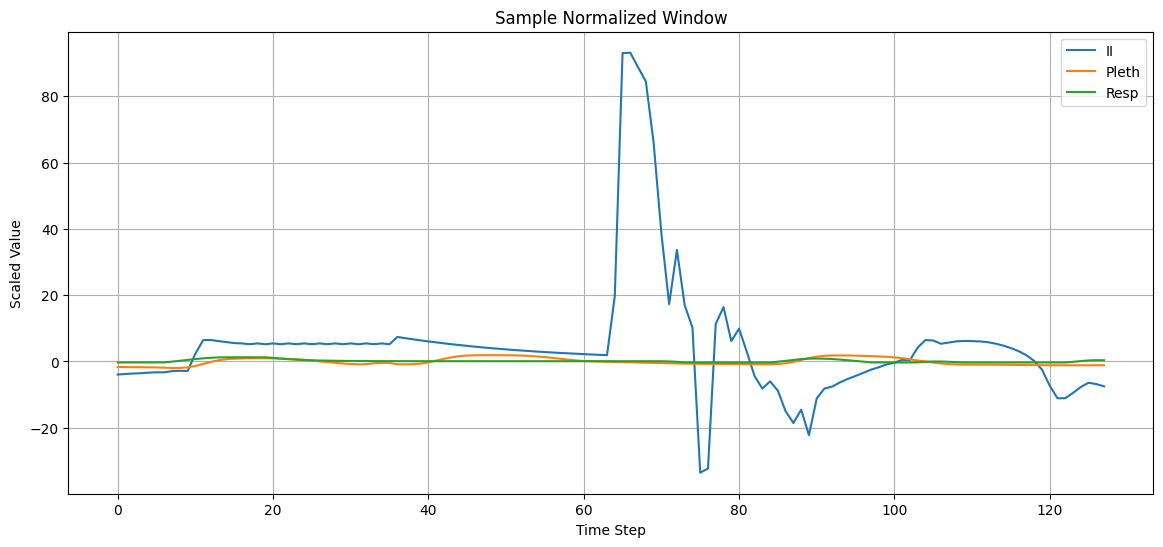

In [ ]:
# ============================================
# Plot one sample normalized window
# ============================================

import matplotlib.pyplot as plt

sample_window = X[0]

plt.figure(figsize=(14, 6))
for i, col in enumerate(signal_cols):
    plt.plot(sample_window[:, i], label=col)

plt.legend()
plt.title("Sample Normalized Window")
plt.xlabel("Time Step")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.show()

In [ ]:
# ============================================
#  Save windowed dataset
# ============================================

np.save("/content/drive/MyDrive/mimic_waveform_project/windowed_data.npy", X)

print("Windowed dataset saved to Drive.")

Windowed dataset saved to Drive.


**Feature engineering**

In [ ]:
# ============================================
#  Extract statistical features
# ============================================

def extract_window_features(windows):
    features = []

    for w in windows:
        feat = []
        for ch in range(w.shape[1]):
            signal = w[:, ch]
            feat.extend([
                np.mean(signal),
                np.std(signal),
                np.min(signal),
                np.max(signal),
                np.median(signal)
            ])
        features.append(feat)

    return np.array(features)

X_features = extract_window_features(X)

print("Feature matrix shape:", X_features.shape)

Feature matrix shape: (12474, 15)


In [ ]:
# ============================================
#  Save feature matrix
# ============================================

np.save("/content/drive/MyDrive/mimic_waveform_project/window_features.npy", X_features)

print("Feature matrix saved to Drive.")

Feature matrix saved to Drive.


**Baseline model**

In [ ]:
# ============================================
# Train Isolation Forest baseline
# ============================================

from sklearn.ensemble import IsolationForest
import numpy as np

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_features)

iso_scores = -iso_model.decision_function(X_features)
iso_preds = iso_model.predict(X_features)               # -1 anomaly, 1 normal

print("Isolation Forest anomaly count:", np.sum(iso_preds == -1))
print("Isolation Forest score shape:", iso_scores.shape)

Isolation Forest anomaly count: 624
Isolation Forest score shape: (12474,)


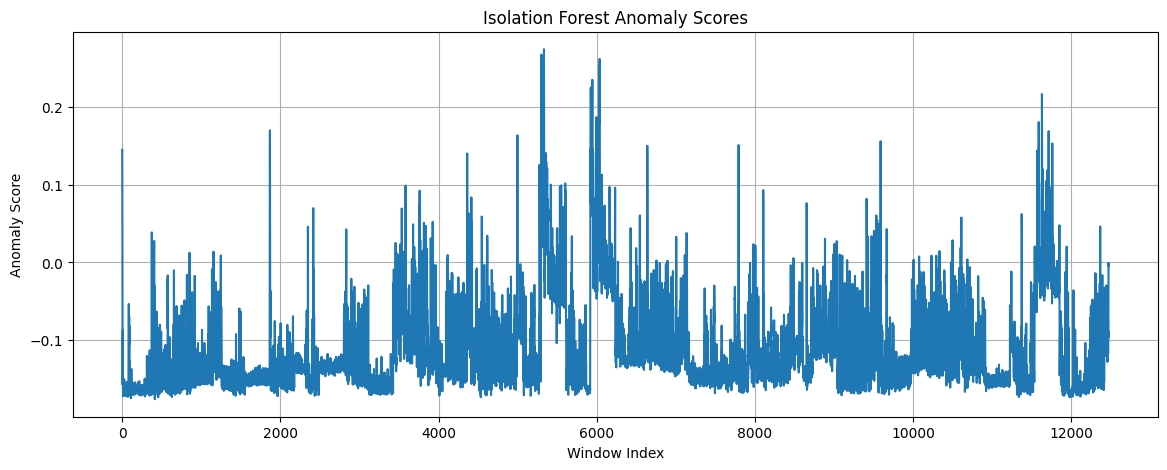

In [ ]:
# ============================================
# Plot Isolation Forest anomaly scores
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(iso_scores)
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Window Index")
plt.ylabel("Anomaly Score")
plt.grid(True)
plt.show()

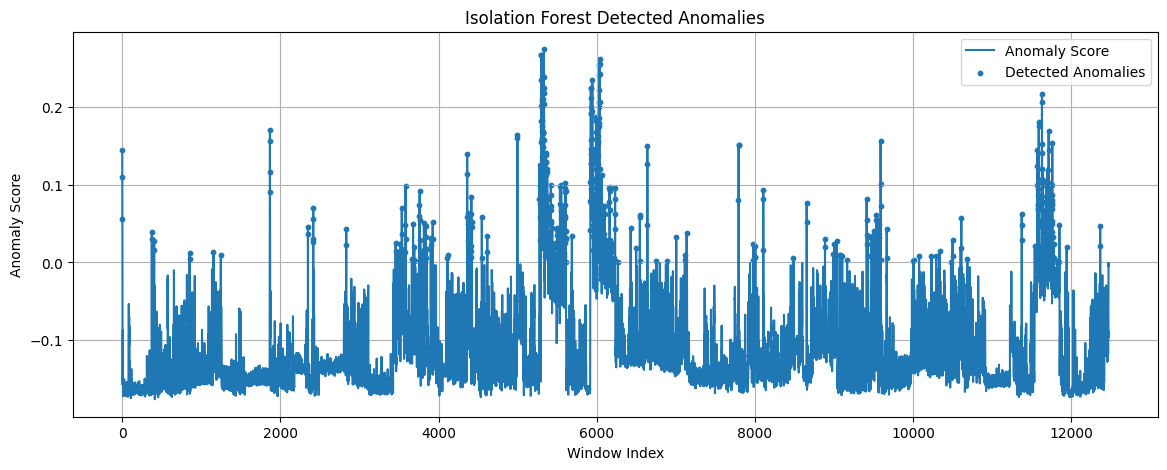

First 20 anomaly indices: [   0    1    2  373  374  403  404  851  852 1154 1247 1866 1867 1868
 1869 2348 2349 2414 2415 2416]


In [ ]:
# ============================================
#  Highlight anomaly windows
# ============================================

anomaly_idx_iso = np.where(iso_preds == -1)[0]

plt.figure(figsize=(14, 5))
plt.plot(iso_scores, label="Anomaly Score")
plt.scatter(anomaly_idx_iso, iso_scores[anomaly_idx_iso], s=10, label="Detected Anomalies")
plt.title("Isolation Forest Detected Anomalies")
plt.xlabel("Window Index")
plt.ylabel("Anomaly Score")
plt.legend()
plt.grid(True)
plt.show()

print("First 20 anomaly indices:", anomaly_idx_iso[:20])

In [ ]:
# ============================================
#  Save Isolation Forest results
# ============================================

np.save("/content/drive/MyDrive/mimic_waveform_project/iso_scores.npy", iso_scores)
np.save("/content/drive/MyDrive/mimic_waveform_project/iso_preds.npy", iso_preds)

print("Isolation Forest results saved to Drive.")

Isolation Forest results saved to Drive.


**Dense Autoencoder**

In [ ]:
# ============================================
#  Train-test split
# ============================================

split_idx = int(0.8 * len(X))
X_train = X[:split_idx]
X_test = X[split_idx:]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (9979, 128, 3)
Test shape : (2495, 128, 3)


In [ ]:
# ============================================
#  Flatten data for Dense Autoencoder
# ============================================

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

input_dim = X_train_flat.shape[1]

print("Flattened train shape:", X_train_flat.shape)
print("Flattened test shape :", X_test_flat.shape)
print("Input dimension      :", input_dim)

Flattened train shape: (9979, 384)
Flattened test shape : (2495, 384)
Input dimension      : 384


In [ ]:
# ============================================
#  Build Dense Autoencoder
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

dense_autoencoder = Model(input_layer, decoded)
dense_autoencoder.compile(optimizer='adam', loss='mse')

dense_autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 384)            │        49,536 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,584 (467.12 KB)

 Trainable params: 119,584 (467.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# Train Dense Autoencoder
# ============================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_dense = dense_autoencoder.fit(
    X_train_flat, X_train_flat,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.8060 - val_loss: 0.3204
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6013 - val_loss: 0.2802
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5579 - val_loss: 0.2718
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5053 - val_loss: 0.2546
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4710 - val_loss: 0.2403
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4415 - val_loss: 0.2299
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4340 - val_loss: 0.2277
Epoch 8/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4251 - val_loss: 0.2204
Epoch 9/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3937 - val_loss: 0.2241
Epoch 10/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3778 - val_loss: 0.2221
Epoch 11/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3515 - val_loss: 0.2310
Epoch 12/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

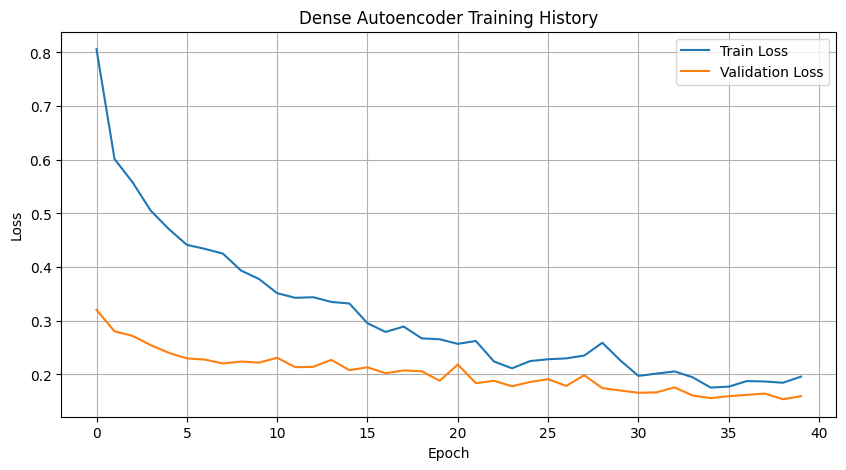

In [ ]:
# ============================================
#  Plot Dense Autoencoder training history
# ============================================

plt.figure(figsize=(10, 5))
plt.plot(history_dense.history['loss'], label='Train Loss')
plt.plot(history_dense.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Dense Autoencoder Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
# ============================================
#  Compute Dense Autoencoder anomaly scores
# ============================================

X_test_pred = dense_autoencoder.predict(X_test_flat)
recon_error_dense = np.mean(np.square(X_test_flat - X_test_pred), axis=1)

print("Dense AE anomaly scores shape:", recon_error_dense.shape)
print("Min reconstruction error:", recon_error_dense.min())
print("Max reconstruction error:", recon_error_dense.max())
print("Mean reconstruction error:", recon_error_dense.mean())

78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
Dense AE anomaly scores shape: (2495,)
Min reconstruction error: 0.0022130108344009356
Max reconstruction error: 2.7852539680010366
Mean reconstruction error: 0.11021445314212759


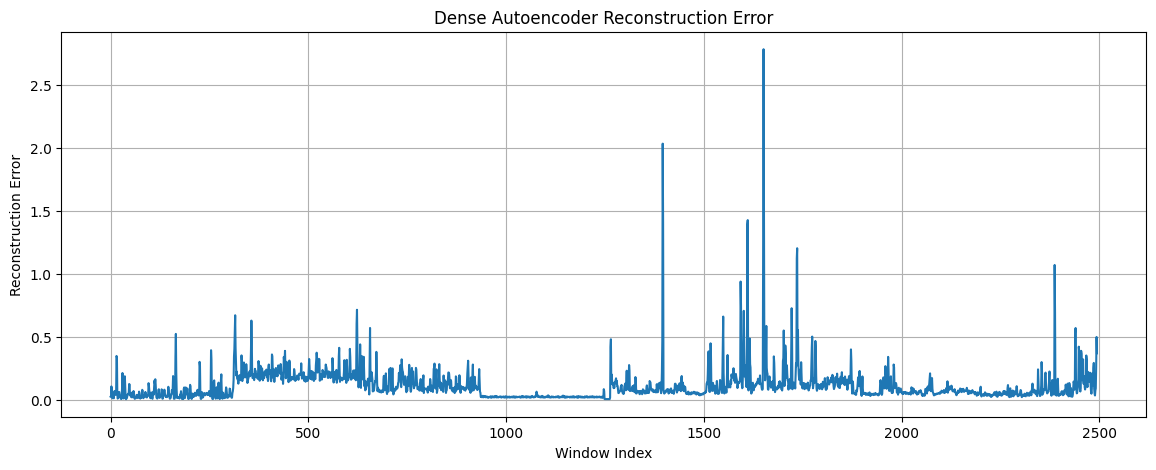

In [ ]:
# ============================================
#  Plot Dense Autoencoder anomaly scores
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(recon_error_dense)
plt.title("Dense Autoencoder Reconstruction Error")
plt.xlabel("Window Index")
plt.ylabel("Reconstruction Error")
plt.grid(True)
plt.show()

In [ ]:
# ============================================
#  Dense AE threshold
# ============================================

dense_threshold = np.percentile(recon_error_dense, 95)
dense_alerts = recon_error_dense > dense_threshold

print("Dense AE threshold:", dense_threshold)
print("Dense AE anomaly windows:", np.sum(dense_alerts))

Dense AE threshold: 0.283930273228372
Dense AE anomaly windows: 125


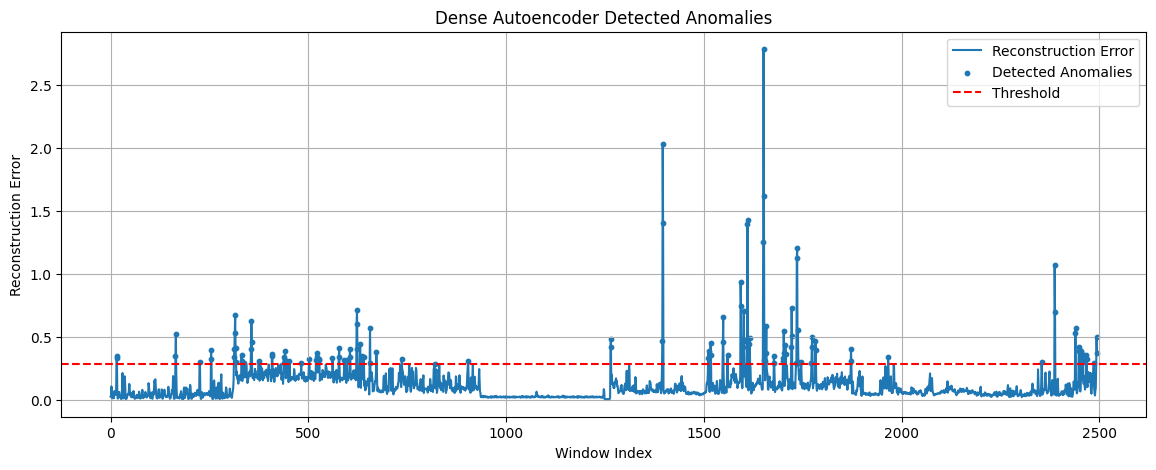

In [ ]:
# ============================================
#  Plot Dense AE detected anomalies
# ============================================

dense_anomaly_idx = np.where(dense_alerts)[0]

plt.figure(figsize=(14, 5))
plt.plot(recon_error_dense, label="Reconstruction Error")
plt.scatter(dense_anomaly_idx, recon_error_dense[dense_anomaly_idx], s=10, label="Detected Anomalies")
plt.axhline(dense_threshold, color='red', linestyle='--', label='Threshold')
plt.title("Dense Autoencoder Detected Anomalies")
plt.xlabel("Window Index")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================
#  Save Dense AE results
# ============================================

np.save("/content/drive/MyDrive/mimic_waveform_project/recon_error_dense.npy", recon_error_dense)
np.save("/content/drive/MyDrive/mimic_waveform_project/dense_alerts.npy", dense_alerts)

print("Dense Autoencoder results saved to Drive.")

Dense Autoencoder results saved to Drive.


**LSTM Autoencoder**

In [ ]:
# ============================================
#  Build LSTM Autoencoder
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

timesteps = X_train.shape[1]
n_features = X_train.shape[2]

lstm_autoencoder = Sequential([
    LSTM(64, activation='tanh', input_shape=(timesteps, n_features), return_sequences=False),
    RepeatVector(timesteps),
    LSTM(64, activation='tanh', return_sequences=True),
    TimeDistributed(Dense(n_features))
])

lstm_autoencoder.compile(optimizer='adam', loss='mse')
lstm_autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 128, 3)         │           195 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,627 (197.76 KB)

 Trainable params: 50,627 (197.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# Train LSTM Autoencoder
# ============================================

early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_lstm = lstm_autoencoder.fit(
    X_train, X_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - loss: 0.8832 - val_loss: 0.4854
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.8495 - val_loss: 0.4728
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.8299 - val_loss: 0.4558
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.8107 - val_loss: 0.4441
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.7987 - val_loss: 0.4348
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.7853 - val_loss: 0.4443
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.7843 - val_loss: 0.4492
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.7804 - val_loss: 0.4205
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.7571 - val_loss: 0.4470
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.7591 - val_loss: 0.3824
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.7149 - val_loss: 0.3758
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━

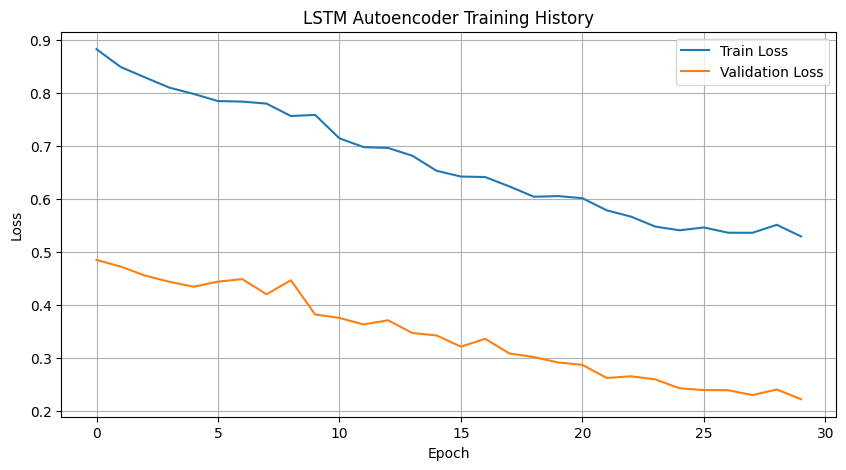

In [ ]:
# ============================================
#  Plot LSTM training history
# ============================================

plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("LSTM Autoencoder Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# Compute LSTM anomaly scores
# ============================================

X_test_pred_lstm = lstm_autoencoder.predict(X_test)
recon_error_lstm = np.mean(np.square(X_test - X_test_pred_lstm), axis=(1, 2))

print("LSTM AE anomaly scores shape:", recon_error_lstm.shape)
print("Min reconstruction error:", recon_error_lstm.min())
print("Max reconstruction error:", recon_error_lstm.max())
print("Mean reconstruction error:", recon_error_lstm.mean())

78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
LSTM AE anomaly scores shape: (2495,)
Min reconstruction error: 0.003349461164123716
Max reconstruction error: 5.601236468789312
Mean reconstruction error: 0.17121741821372047


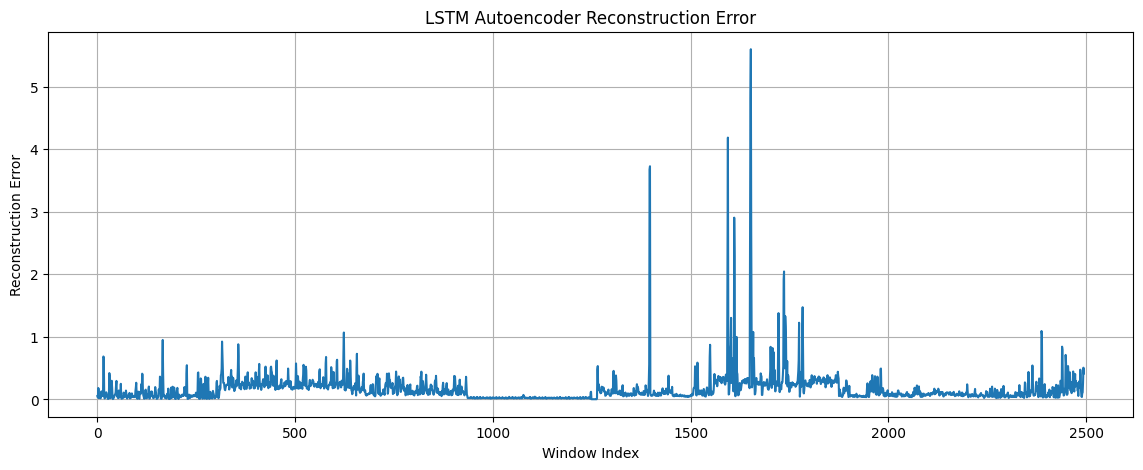

In [ ]:
# ============================================
#  Plot LSTM reconstruction error
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(recon_error_lstm)
plt.title("LSTM Autoencoder Reconstruction Error")
plt.xlabel("Window Index")
plt.ylabel("Reconstruction Error")
plt.grid(True)
plt.show()

In [ ]:
# ============================================
#  Set LSTM threshold
# ============================================

lstm_threshold = np.percentile(recon_error_lstm, 95)
lstm_alerts = recon_error_lstm > lstm_threshold

print("LSTM AE threshold:", lstm_threshold)
print("LSTM AE anomaly windows:", np.sum(lstm_alerts))

LSTM AE threshold: 0.433452903171855
LSTM AE anomaly windows: 125


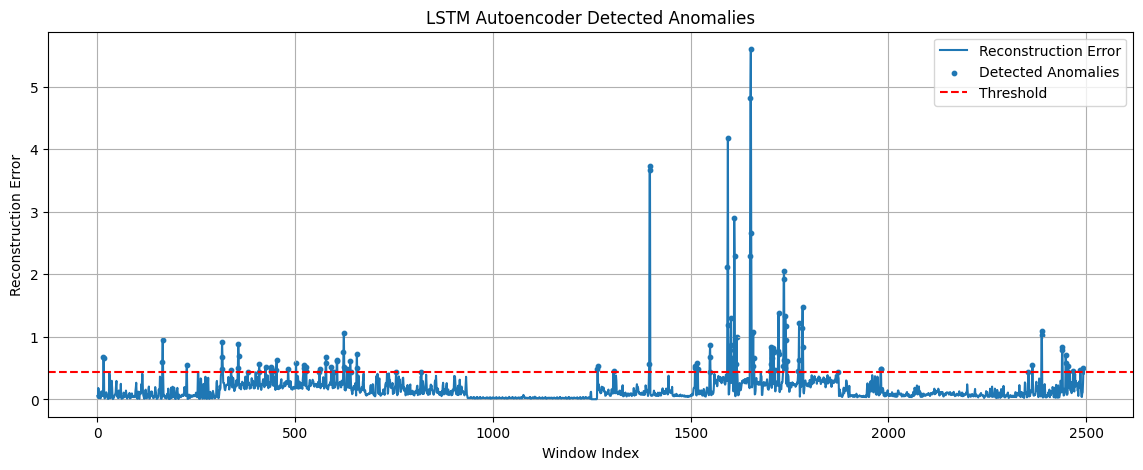

In [ ]:
# ============================================
# Plot LSTM detected anomalies
# ============================================

lstm_anomaly_idx = np.where(lstm_alerts)[0]

plt.figure(figsize=(14, 5))
plt.plot(recon_error_lstm, label="Reconstruction Error")
plt.scatter(lstm_anomaly_idx, recon_error_lstm[lstm_anomaly_idx], s=10, label="Detected Anomalies")
plt.axhline(lstm_threshold, color='red', linestyle='--', label='Threshold')
plt.title("LSTM Autoencoder Detected Anomalies")
plt.xlabel("Window Index")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================
#  Save LSTM AE results
# ============================================

np.save("/content/drive/MyDrive/mimic_waveform_project/recon_error_lstm.npy", recon_error_lstm)
np.save("/content/drive/MyDrive/mimic_waveform_project/lstm_alerts.npy", lstm_alerts)

print("LSTM Autoencoder results saved to Drive.")

LSTM Autoencoder results saved to Drive.


**Model comparison and final evaluation**

In [ ]:
# ============================================
# Comparing anomaly counts
# ============================================

comparison_df = pd.DataFrame({
    "Model": ["Isolation Forest", "Dense Autoencoder", "LSTM Autoencoder"],
    "Detected_Anomalies": [
        int(np.sum(iso_preds == -1)),
        int(np.sum(dense_alerts)),
        int(np.sum(lstm_alerts))
    ]
})

comparison_df

,Model,Detected_Anomalies
0,Isolation Forest,624
1,Dense Autoencoder,125
2,LSTM Autoencoder,125


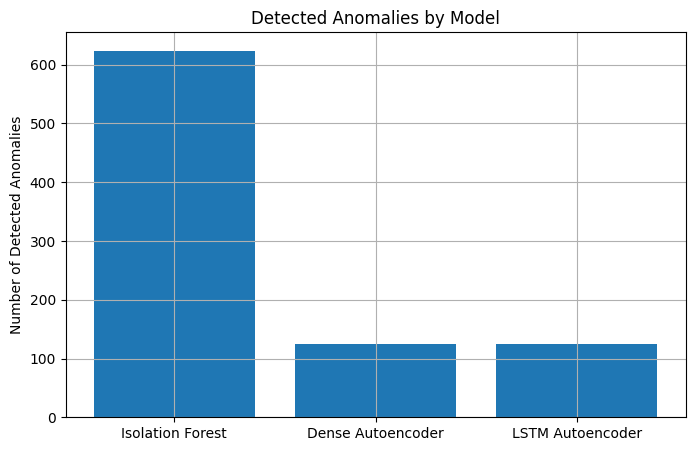

In [ ]:
# ============================================
#  Bar plot of anomaly counts
# ============================================

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Detected_Anomalies"])
plt.title("Detected Anomalies by Model")
plt.ylabel("Number of Detected Anomalies")
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# Score summary table
# ============================================

score_summary_df = pd.DataFrame({
    "Model": ["Isolation Forest", "Dense Autoencoder", "LSTM Autoencoder"],
    "Mean_Score": [
        float(np.mean(iso_scores)),
        float(np.mean(recon_error_dense)),
        float(np.mean(recon_error_lstm))
    ],
    "Max_Score": [
        float(np.max(iso_scores)),
        float(np.max(recon_error_dense)),
        float(np.max(recon_error_lstm))
    ],
    "Min_Score": [
        float(np.min(iso_scores)),
        float(np.min(recon_error_dense)),
        float(np.min(recon_error_lstm))
    ]
})

score_summary_df

,Model,Mean_Score,Max_Score,Min_Score
0,Isolation Forest,-0.111042,0.274392,-0.176060
1,Dense Autoencoder,0.110214,2.785254,0.002213
2,LSTM Autoencoder,0.171217,5.601236,0.003349


In [ ]:
# ============================================
#  Comparing overlap between models
# ============================================

iso_anomaly_idx = set(np.where(iso_preds == -1)[0])
dense_anomaly_idx = set(np.where(dense_alerts)[0])
lstm_anomaly_idx = set(np.where(lstm_alerts)[0])

overlap_df = pd.DataFrame({
    "Comparison": [
        "IF vs Dense AE",
        "IF vs LSTM AE",
        "Dense AE vs LSTM AE"
    ],
    "Common_Anomalies": [
        len(iso_anomaly_idx & dense_anomaly_idx),
        len(iso_anomaly_idx & lstm_anomaly_idx),
        len(dense_anomaly_idx & lstm_anomaly_idx)
    ]
})

overlap_df

,Comparison,Common_Anomalies
0,IF vs Dense AE,1
1,IF vs LSTM AE,0
2,Dense AE vs LSTM AE,96


First anomaly indices: [ 15  16 164 165 226 314 315 316 338 355]


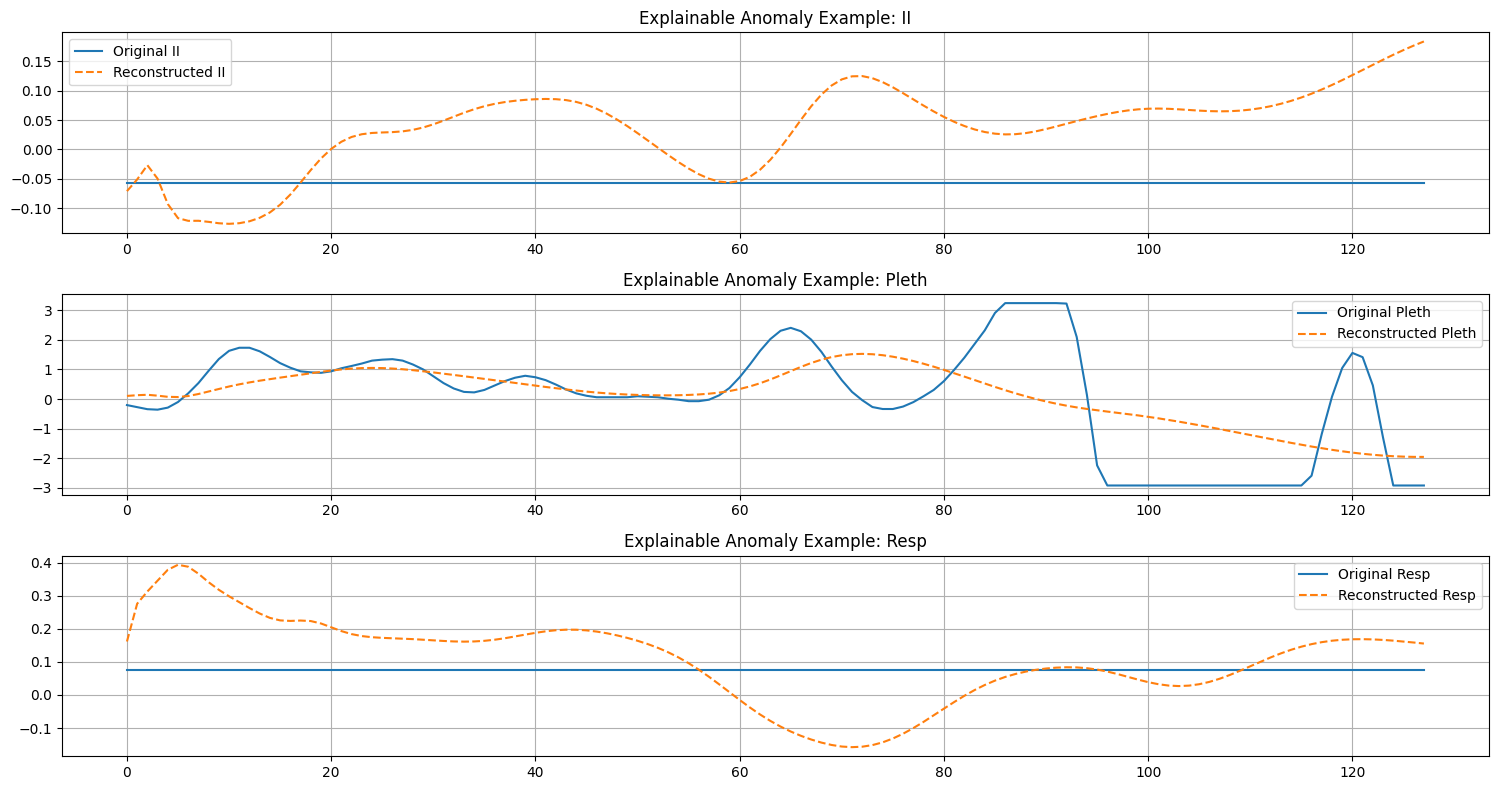

In [ ]:
# ============================================
#  Plot explainable anomaly
# ============================================

anomaly_indices = np.where(lstm_alerts)[0]
print("First anomaly indices:", anomaly_indices[:10])

idx = anomaly_indices[0] if len(anomaly_indices) > 0 else 0

orig = X_test[idx]
recon = X_test_pred_lstm[idx]

plt.figure(figsize=(15, 8))

for i, col in enumerate(signal_cols):
    plt.subplot(len(signal_cols), 1, i+1)
    plt.plot(orig[:, i], label=f"Original {col}")
    plt.plot(recon[:, i], label=f"Reconstructed {col}", linestyle='--')
    plt.legend()
    plt.title(f"Explainable Anomaly Example: {col}")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
#  Save comparison tables
# ============================================

comparison_df.to_csv("/content/drive/MyDrive/mimic_waveform_project/model_anomaly_counts.csv", index=False)
score_summary_df.to_csv("/content/drive/MyDrive/mimic_waveform_project/model_score_summary.csv", index=False)
overlap_df.to_csv("/content/drive/MyDrive/mimic_waveform_project/model_overlap_summary.csv", index=False)

print("Comparison tables saved to Drive.")

Comparison tables saved to Drive.
